## testing some of the access model's analysis using references

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [5]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, cbar_orientation='vertical', hatch_type = 'insig'):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [6]:
from functions import preproc_funcs as funcs

In [7]:
from functions import xr_lowess

#### import data

In [8]:
ts_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_ts.nc').ts
pr_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_pr.nc').pr*86400*30

In [9]:
ts_trans1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp1_ts.nc').ts
pr_trans1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp1_pr.nc').pr*86400*30

In [10]:
ts_trans2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp2_ts.nc').ts
pr_trans2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp2_pr.nc').pr*86400*30

In [11]:
ts_trans5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5o_ts.nc').ts
pr_trans5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5o_pr.nc').pr*86400*30

In [12]:
ts_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable.nc').ts
pr_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_pr.nc').pr*86400*30

In [13]:
pr_trans_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_pr_original.nc').pr*86400*30

In [14]:
pr_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_pr_original.nc').resample(time = 'AS-JUN').mean('time').load().pr*86400*30

### analyiss

In [15]:
weights_model = np.cos(np.deg2rad(ts_stable.lat))
weights_model.name='weights'
weights_model

<xarray.DataArray 'weights' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [16]:
gmst_trans1 = ts_trans1.weighted(weights_model).mean(('lat', 'lon'))
# gmst_trans2 = ts_trans2.weighted(weights_model).mean(('lat', 'lon'))
gmst_trans5o = ts_trans5o.weighted(weights_model).mean(('lat', 'lon'))
gmst_trans = ts_trans.weighted(weights_model).mean(('lat', 'lon'))

In [17]:
gmst_stable = ts_stable.weighted(weights_model).mean(('lat', 'lon'))

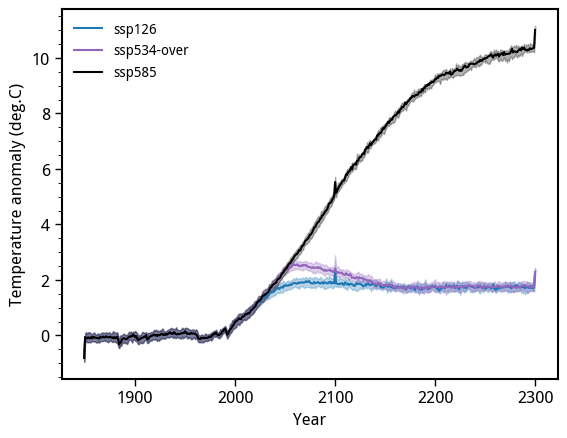

In [18]:
plt.plot(gmst_trans1.time.dt.year, gmst_trans1.quantile(0.5, 'model'), color='tab:blue', label='ssp126')
plt.fill_between(gmst_trans1.time.dt.year, gmst_trans1.quantile(0.1, 'model'), gmst_trans1.quantile(0.9, 'model'), color='tab:blue', alpha=0.3)

plt.plot(gmst_trans5o.time.dt.year, gmst_trans5o.quantile(0.5, 'model'), color='tab:purple', label='ssp534-over')
plt.fill_between(gmst_trans5o.time.dt.year, gmst_trans5o.quantile(0.1, 'model'), gmst_trans5o.quantile(0.9, 'model'), color='tab:purple', alpha=0.3)

plt.plot(gmst_trans.time.dt.year, gmst_trans.quantile(0.5, 'model'), color='k', label='ssp585')
plt.fill_between(gmst_trans.time.dt.year, gmst_trans.quantile(0.1, 'model'), gmst_trans.quantile(0.9, 'model'), color='k', alpha=0.3)

plt.legend(frameon=False, fontsize=10)
plt.ylabel('Temperature anomaly (deg.C)')
plt.xlabel('Year')
plt.minorticks_on()
plt.gca().tick_params(bottom=False, which='minor', axis='x')

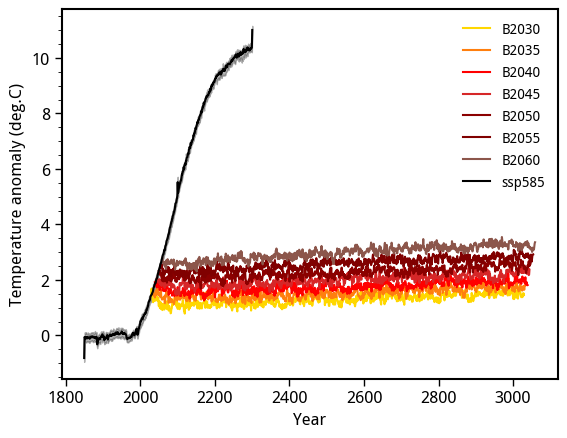

In [19]:
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2030'), label='B2030', color='gold')
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2035'), label='B2035', color='tab:orange')
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2040'), label='B2040', color='red')
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2045'), label='B2045', color='tab:red')
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2050'), label='B2050', color='darkred')
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2055'), label='B2055', color='maroon')
plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2060'), label='B2060', color='tab:brown')

plt.plot(gmst_trans.time.dt.year, gmst_trans.quantile(0.5, 'model'), color='k', label='ssp585')
plt.fill_between(gmst_trans.time.dt.year, gmst_trans.quantile(0.1, 'model'), gmst_trans.quantile(0.9, 'model'), color='k', alpha=0.3)

plt.legend(frameon=False, fontsize=10)
plt.ylabel('Temperature anomaly (deg.C)')
plt.xlabel('Year')
plt.minorticks_on()
plt.gca().tick_params(bottom=False, which='minor', axis='x')

In [20]:
def rolling_window_smoothing(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    smoothed_data = padded_data.rolling(time=window_size, center=True).mean('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return smoothed_data

In [21]:
def rolling_window_std(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    std_data = padded_data.rolling(time=window_size, center=True).std('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return std_data

In [22]:
base = ts_trans.isel(time = 0, model=0)
base

<xarray.DataArray 'ts' (lat: 120, lon: 240)>
array([[ 2.422684,  2.434921,  2.432266, ...,  2.397446,  2.399765,  2.403519],
       [ 2.241837,  2.264511,  2.283478, ...,  2.185989,  2.201935,  2.212891],
       [ 2.142441,  2.19104 ,  2.230255, ...,  2.020157,  2.057632,  2.096085],
       ...,
       [-7.575516, -7.593842, -7.621674, ..., -7.548553, -7.552521, -7.560181],
       [-8.021118, -8.020996, -8.031784, ..., -8.013962, -8.011307, -8.012024],
       [-8.604248, -8.605194, -8.607285, ..., -8.601776, -8.600159, -8.602905]],
      dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
    time     object 1849-06-01 00:00:00
    model    <U22 'ACCESS-ESM1-5_r6i1p1f1'

In [23]:
def additional_sampling_stabilisation(da):
    i = 0
    da_list = []
    while i <= 960:
        sample_da = da.isel(time = slice(i,i+40)).mean('time')
        da_list.append(sample_da)
        i += 40
    print(len(da_list))
    return xr.concat(da_list, dim=np.arange(0, 25, 1)).drop('model').rename(dict(concat_dim='model'))


In [24]:
additional_sampling_stabilisation(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060')))

25


<xarray.DataArray 'ts' (model: 25, lat: 120, lon: 240)>
array([[[2.0387816, 2.0534909, 2.0641065, ..., 2.0045333, 2.0141535,
         2.0236125],
        [2.5905852, 2.609103 , 2.6113782, ..., 2.5675182, 2.570105 ,
         2.572039 ],
        [2.7524843, 2.7927802, 2.7985911, ..., 2.6889806, 2.6993167,
         2.7092175],
        ...,
        [9.135007 , 9.136488 , 9.151154 , ..., 9.1193695, 9.127559 ,
         9.139631 ],
        [9.39092  , 9.39432  , 9.404484 , ..., 9.378155 , 9.382213 ,
         9.386804 ],
        [9.436937 , 9.433247 , 9.432306 , ..., 9.437891 , 9.43709  ,
         9.437558 ]],

       [[2.1905627, 2.204598 , 2.2135003, ..., 2.160396 , 2.1687675,
         2.1772003],
        [2.6758313, 2.6915178, 2.690641 , ..., 2.6625936, 2.661714 ,
         2.6603806],
        [2.806958 , 2.8435028, 2.8460784, ..., 2.7583466, 2.763034 ,
         2.7675729],
...
        [9.478834 , 9.475993 , 9.486054 , ..., 9.488057 , 9.48435  ,
         9.485552 ],
        [9.718785 , 9.720844 , 9.726551 , ..., 9.708551 , 9.715983 ,
         9.718797 ],
        [9.82187  , 9.817539 , 9.815742 , ..., 9.820295 , 9.820192 ,
         9.822142 ]],

       [[4.5147123, 4.5296946, 4.5402203, ..., 4.4795794, 4.4891405,
         4.4992185],
        [5.0323153, 5.0508413, 5.0533495, ..., 5.010718 , 5.0125465,
         5.014531 ],
        [5.246504 , 5.2869086, 5.292365 , ..., 5.186741 , 5.195595 ,
         5.204162 ],
        ...,
        [8.277801 , 8.286995 , 8.305594 , ..., 8.261536 , 8.266822 ,
         8.276346 ],
        [8.573131 , 8.573544 , 8.579172 , ..., 8.56104  , 8.564832 ,
         8.568837 ],
        [8.691073 , 8.687548 , 8.686369 , ..., 8.693422 , 8.692324 ,
         8.692135 ]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * model    (model) int64 0 1 2 3 4 5 6 7 8 9 ... 15 16 17 18 19 20 21 22 23 24

In [70]:
plot_list = [
    # ts_trans.where((gmst_trans < 3.1) & (gmst_trans > 2.9)).mean(('time', 'model')),
    # ts_stable.where((gmst_stable < 3.1) & (gmst_stable > 2.9)).mean(('time', 'model')),
    # ts_trans.where((gmst_trans < 2.1) & (gmst_trans > 1.9)).mean(('time', 'model')),
    # ts_stable.where((gmst_stable < 2.1) & (gmst_stable > 1.9)).mean(('time', 'model')),
    # ts_trans.where((gmst_trans < 1.7) & (gmst_trans > 1.3)).mean(('time', 'model')),
    # ts_stable.where((gmst_stable < 1.7) & (gmst_stable > 1.3)).mean(('time', 'model')),
    ts_trans.sel(time = slice('2045', '2075')).mean(('time', 'model')),
    additional_sampling_stabilisation(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060'))).mean('model'),
    ts_trans.sel(time = slice('2030', '2060')).mean(('time', 'model')),
    additional_sampling_stabilisation(ts_stable.sel(model = 'B2045').sel(time = slice('2045', '3045'))).mean('model'),
    ts_trans.sel(time = slice('2015', '2045')).mean(('time', 'model')),
    additional_sampling_stabilisation(ts_stable.sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean('model'),
]

25
25
25


In [71]:
titles_list = [
    # 'ssp585 GWL: 3degC',
    # 'NZ GWL: 3degC',
    # 'ssp585 GWL: 2degC',
    # 'NZ GWL: 2degC',
    # 'ssp585 GWL: 1.5degC',
    # 'NZ GWL: 1.5degC',
    'ssp585 [2045-2075]',
    'NZ B2060',
    'ssp585 [2030-2060]',
    'NZ B2045',
    'ssp585 [2015-2045]',
    'NZ B2030',
]

In [72]:
xx, yy = np.meshgrid(base.lon, base.lat)

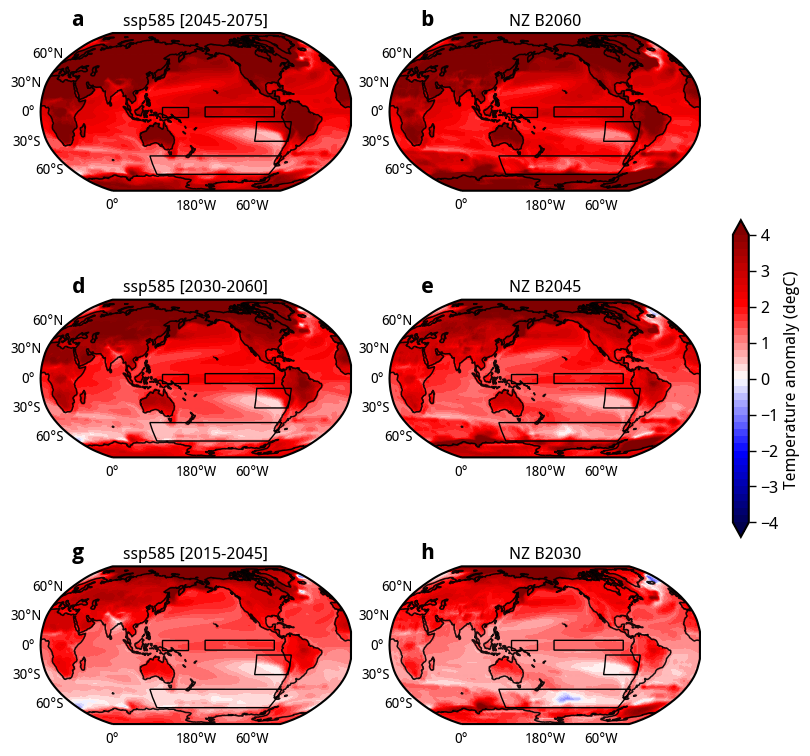

In [73]:
plot_maps(xx, yy, plot_list, titles_list, labels=['a', 'b', 'd', 'e', 'g', 'h'], cmap='seismic', levels=np.arange(-4, 4.2, 0.2), cbar_label = 'Temperature anomaly (degC)', pval = [], nrows=3, ncols=2, figsize=(8,8), land_mask_list = [], add_patch=True, cbar_orientation='vertical')

In [61]:
# making 3d version of mann whitney u test
def ks_1d(dist1, dist2):
    return float(stats.ks_2samp(dist1, dist2).pvalue)


def ks_3d(da1, da2, dim):
    return xr.apply_ufunc(ks_1d, da1, da2, input_core_dims=[[dim], [dim]], exclude_dims={dim, dim}, vectorize=True, dask='parallelized')

In [62]:
plot_list = [
    additional_sampling_stabilisation(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060'))).mean('model') - ts_trans.sel(time = slice('2045', '2075')).mean(('time', 'model')),
    additional_sampling_stabilisation(ts_stable.sel(model = 'B2045').sel(time = slice('2045', '3045'))).mean('model') - ts_trans.sel(time = slice('2030', '2060')).mean(('time', 'model')),
    additional_sampling_stabilisation(ts_stable.sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean('model') - ts_trans.sel(time = slice('2015', '2045')).mean(('time', 'model')),
]

25
25
25


In [64]:
pval_list = [
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060'))), ts_trans.sel(time = slice('2045', '2075')).mean(('time')), dim='model'),
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(ts_stable.sel(model = 'B2045').sel(time = slice('2045', '3045'))), ts_trans.sel(time = slice('2030', '2060')).mean(('time')), dim='model'),
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(ts_stable.sel(model = 'B2030').sel(time = slice('2030', '3030'))), ts_trans.sel(time = slice('2015', '2045')).mean(('time')), dim='model'),
]

25
25
25


In [65]:
titles_list = [
    'DIFF GWL: 2060',
    'DIFF GWL: 2045',
    'DIFF GWL: 2030',
]


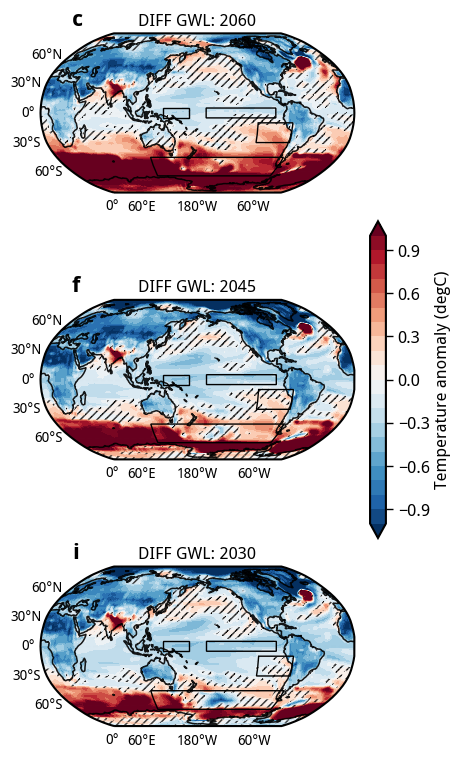

In [66]:
plot_maps(xx, yy, plot_list, titles_list, labels=['c', 'f', 'i'], cmap='RdBu_r', levels=np.arange(-1, 1.1, 0.1), cbar_label = 'Temperature anomaly (degC)', pval = pval_list, nrows=3, ncols=1, figsize=(4.5,8), land_mask_list = [], add_patch=True, cbar_orientation='vertical')

In [67]:
pr_trans['model'] = gmst_trans['model']
pr_stable['model'] = gmst_stable['model']

In [25]:
pr_standardizer = pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model') 

In [74]:
plot_list = [
    # pr_trans.where((gmst_trans < 3.1) & (gmst_trans > 2.9)).mean(('time', 'model'))/pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model'),
    # pr_stable.where((gmst_stable < 3.1) & (gmst_stable > 2.9)).mean(('time', 'model'))/pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model'),
    # pr_trans.where((gmst_trans < 2.1) & (gmst_trans > 1.9)).mean(('time', 'model'))/pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model'),
    # pr_stable.where((gmst_stable < 2.1) & (gmst_stable > 1.9)).mean(('time', 'model'))/pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model'),
    # pr_trans.where((gmst_trans < 1.7) & (gmst_trans > 1.3)).mean(('time', 'model'))/pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model'),
    # pr_stable.where((gmst_stable < 1.7) & (gmst_stable > 1.3)).mean(('time', 'model'))/pr_trans.sel(time = slice('1850', '1900')).std('time').mean('model'),
    pr_trans.sel(time = slice('2045', '2075')).mean(('time', 'model'))/pr_standardizer,
    additional_sampling_stabilisation(pr_stable.sel(model = 'B2060').sel(time = slice('2060', '3060'))).mean('model')/pr_standardizer,
    pr_trans.sel(time = slice('2030', '2060')).mean(('time', 'model'))/pr_standardizer,
    additional_sampling_stabilisation(pr_stable.sel(model = 'B2045').sel(time = slice('2045', '3045'))).mean('model')/pr_standardizer,
    pr_trans.sel(time = slice('2015', '2045')).mean(('time', 'model'))/pr_standardizer,
    additional_sampling_stabilisation(pr_stable.sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean('model')/pr_standardizer,
]

25
25
25


In [75]:
titles_list = [
    # 'ssp585 GWL: 3degC',
    # 'NZ GWL: 3degC',
    # 'ssp585 GWL: 2degC',
    # 'NZ GWL: 2degC',
    # 'ssp585 GWL: 1.5degC',
    # 'NZ GWL: 1.5degC',
    'ssp585 [2045-2075]',
    'NZ B2060',
    'ssp585 [2030-2060]',
    'NZ B2045',
    'ssp585 [2015-2045]',
    'NZ B2030',
]

In [76]:
xx, yy = np.meshgrid(base.lon, base.lat)

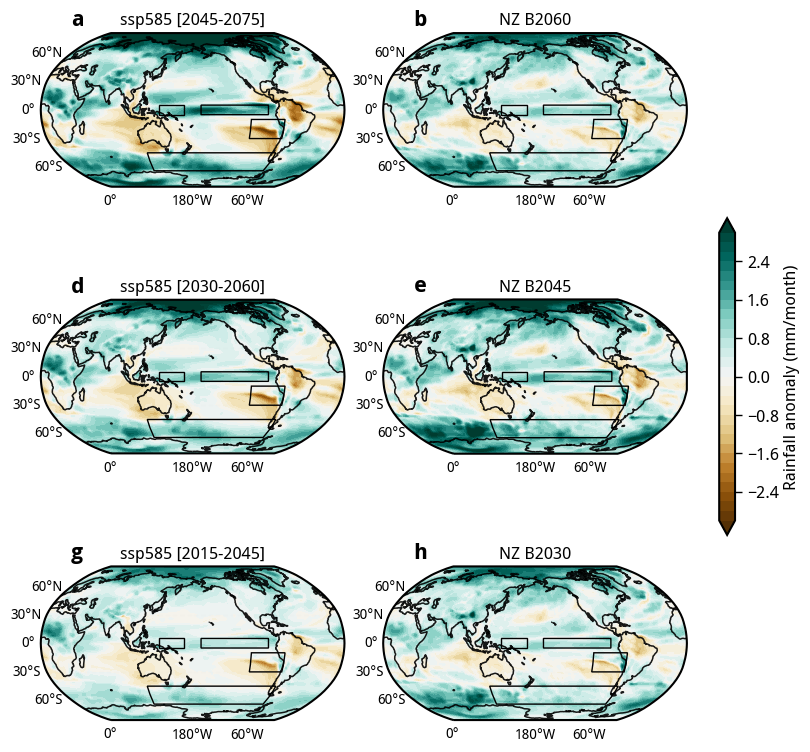

In [77]:
plot_maps(xx, yy, plot_list, titles_list, labels=['a', 'b', 'd', 'e', 'g', 'h'], cmap='BrBG', levels=np.arange(-3, 3.2, 0.2), cbar_label = 'Rainfall anomaly (mm/month)', pval = [], nrows=3, ncols=2, figsize=(8,8), land_mask_list = [], add_patch=True, cbar_orientation='vertical')

In [78]:
plot_list = [
    additional_sampling_stabilisation(pr_stable.sel(model = 'B2060').sel(time = slice('2060', '3060'))).mean('model')/pr_standardizer - pr_trans.sel(time = slice('2045', '2075')).mean(('time', 'model'))/pr_standardizer,
    additional_sampling_stabilisation(pr_stable.sel(model = 'B2045').sel(time = slice('2045', '3045'))).mean('model')/pr_standardizer - pr_trans.sel(time = slice('2030', '2060')).mean(('time', 'model'))/pr_standardizer,
    additional_sampling_stabilisation(pr_stable.sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean('model')/pr_standardizer - pr_trans.sel(time = slice('2015', '2045')).mean(('time', 'model'))/pr_standardizer,
]

25
25
25


In [79]:
pval_list = [
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060')))/pr_standardizer, ts_trans.sel(time = slice('2045', '2075')).mean(('time'))/pr_standardizer, dim='model'),
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(ts_stable.sel(model = 'B2045').sel(time = slice('2045', '3045')))/pr_standardizer, ts_trans.sel(time = slice('2030', '2060')).mean(('time'))/pr_standardizer, dim='model'),
    funcs.mannwhitneyu3d(additional_sampling_stabilisation(ts_stable.sel(model = 'B2030').sel(time = slice('2030', '3030')))/pr_standardizer, ts_trans.sel(time = slice('2015', '2045')).mean(('time'))/pr_standardizer, dim='model'),
]

25
25
25


In [80]:
titles_list = [
    'DIFF GWL: 2060',
    'DIFF GWL: 2045',
    'DIFF GWL: 2030',
]


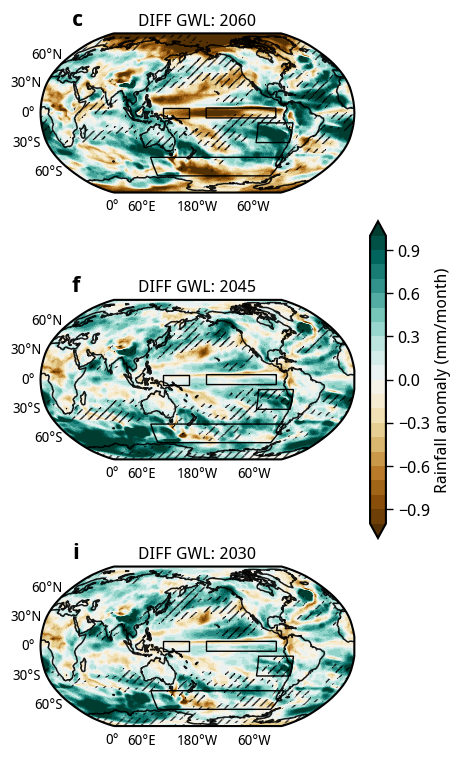

In [83]:
plot_maps(xx, yy, plot_list, titles_list, labels=['c', 'f', 'i'], cmap='BrBG', levels=np.arange(-1.0, 1.1, 0.1), cbar_label = 'Rainfall anomaly (mm/month)', pval = pval_list, nrows=3, ncols=1, figsize=(4.5,8), land_mask_list = [], add_patch=True, cbar_orientation='vertical', hatch_type='insig')

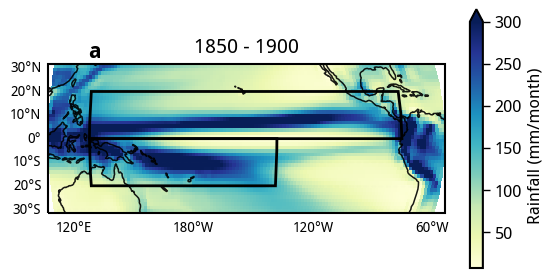

In [85]:
ax = plt.axes(projection = ccrs.Robinson(central_longitude=180))
pr_trans_noanom.sel(lat=slice(-31, 31), lon = slice(110, -60+360)).sel(time = slice('1850', '1900')).mean(('time', 'model')).plot(vmax = 300, cmap='YlGnBu', transform=ccrs.PlateCarree(), cbar_kwargs = dict(label='Rainfall (mm/month)', shrink=0.7))
plot_background(ax)
plt.title('1850 - 1900')
plt.text(0.1, 1.05, 'a', size=16, fontweight='bold', transform=plt.gca().transAxes)
plt.gca().add_patch(mpatches.Rectangle(xy=[130, 0], width=150, height=20,
                                facecolor='none', edgecolor='k', lw=2.0,
                                transform=ccrs.PlateCarree()))
plt.gca().add_patch(mpatches.Rectangle(xy=[130, -20], width=90, height=20,
                                facecolor='none', edgecolor='k', lw=2.0,
                                transform=ccrs.PlateCarree()))

In [24]:
pr_trans_noanom['model'] = gmst_trans['model']

<GeoAxesSubplot:title={'center':'ssp585 [2015-2045]'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

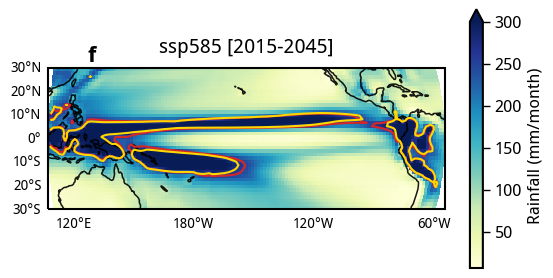

In [94]:
ax = plt.axes(projection = ccrs.Robinson(central_longitude=180))
# pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).where((gmst_trans > 2.9) & (gmst_trans < 3.1)).mean(('time', 'model')).plot(vmax = 300, cmap='YlGnBu', transform=ccrs.PlateCarree(), cbar_kwargs = dict(label='Rainfall (mm/month)', shrink=0.7))
# pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).where((gmst_trans > 2.9) & (gmst_trans < 3.1)).mean(('time', 'model')).plot.contour(levels=[250], colors='tab:red', transform=ccrs.PlateCarree())
# pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(time = slice('1850', '1900')).mean(('time', 'model')).plot.contour(levels=[250], colors='gold', transform=ccrs.PlateCarree())
pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(time = slice('2015', '2045')).mean(('time', 'model')).plot(vmax = 300, cmap='YlGnBu', transform=ccrs.PlateCarree(), cbar_kwargs = dict(label='Rainfall (mm/month)', shrink=0.7))
pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(time = slice('2015', '2045')).mean(('time', 'model')).plot.contour(levels=[250], colors='tab:red', transform=ccrs.PlateCarree())
pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(time = slice('1850', '1900')).mean(('time', 'model')).plot.contour(levels=[250], colors='gold', transform=ccrs.PlateCarree())
plt.title('ssp585 [2015-2045]')
plt.text(0.1, 1.05, 'f', size=16, fontweight='bold', transform=plt.gca().transAxes)
plot_background(ax)
# plt.gca().add_patch(mpatches.Rectangle(xy=[130, 0], width=150, height=20,
#                                 facecolor='none', edgecolor='k', lw=2.0,
#                                 transform=ccrs.PlateCarree()))
# plt.gca().add_patch(mpatches.Rectangle(xy=[130, -20], width=90, height=20,
#                                 facecolor='none', edgecolor='k', lw=2.0,
#                                 transform=ccrs.PlateCarree()))

25
25


<GeoAxesSubplot:title={'center':'NZ B2030'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

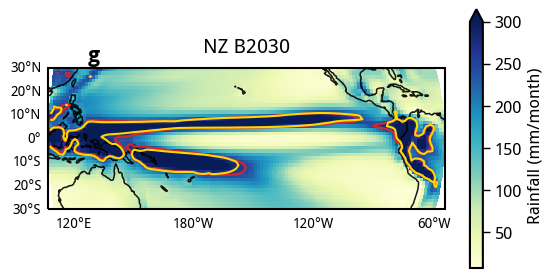

In [95]:
ax = plt.axes(projection = ccrs.Robinson(central_longitude=180))
# pr_stable_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).where((gmst_stable > 2.9) & (gmst_stable < 3.1)).mean(('time', 'model')).plot(vmax = 300, cmap='YlGnBu', transform=ccrs.PlateCarree(), cbar_kwargs = dict(label='Rainfall (mm/month)', shrink=0.7))
# pr_stable_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).where((gmst_stable > 2.9) & (gmst_stable < 3.1)).mean(('time', 'model')).plot.contour(levels=[250], colors='tab:red', transform=ccrs.PlateCarree())
# pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(time = slice('1850', '1900')).mean(('time', 'model')).plot.contour(levels=[250], colors='gold', transform=ccrs.PlateCarree())
additional_sampling_stabilisation(pr_stable_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean(('model')).plot(vmax = 300, cmap='YlGnBu', transform=ccrs.PlateCarree(), cbar_kwargs = dict(label='Rainfall (mm/month)', shrink=0.7))
additional_sampling_stabilisation(pr_stable_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(model = 'B2030').sel(time = slice('2030', '3030'))).mean(('model')).plot.contour(levels=[250], colors='tab:red', transform=ccrs.PlateCarree())
pr_trans_noanom.sel(lat=slice(-30, 30), lon = slice(110, -60+360)).sel(time = slice('1850', '1900')).mean(('time', 'model')).plot.contour(levels=[250], colors='gold', transform=ccrs.PlateCarree())
plt.title('NZ B2030')
plt.text(0.1, 1.05, 'g', size=16, fontweight='bold', transform=plt.gca().transAxes)
plot_background(ax)

In [96]:
test = pr_trans_noanom.sel(time = slice('1850', '1900')).mean(('time')).sel(lat = slice(0,20), lon = slice(130, -80+360))
test

<xarray.DataArray 'pr' (model: 40, lat: 13, lon: 100)>
array([[[343.94761012, 324.07378477, 292.08183449, ..., 165.5945963 ,
         244.92647852, 330.31742709],
        [346.48868761, 328.55665314, 309.83721702, ..., 193.22700792,
         256.74522344, 323.27568139],
        [345.4086424 , 345.36635804, 334.53200886, ..., 233.5257581 ,
         259.54284041, 315.73402346],
        ...,
        [177.65625228, 174.73417976, 171.59349728, ..., 107.99004466,
          95.49255205,  70.02812289],
        [183.44487707, 179.40247851, 174.46039106, ...,  79.7846126 ,
          69.69677468,  57.89789673],
        [181.17489548, 177.82007122, 173.31567127, ...,  77.7174526 ,
          72.62817733,  63.11921278]],

       [[332.56792834, 312.21252289, 278.86265346, ..., 171.53900542,
         253.8890434 , 339.71219069],
        [335.58793563, 317.86724771, 298.71410468, ..., 203.37376876,
         265.30977185, 332.52836027],
        [338.17538477, 339.99313982, 329.83837396, ..., 237.21582977,
         263.88527   , 321.58855664],
...
        [179.74830708, 176.11677906, 173.06176062, ..., 120.92443453,
         108.28260066,  78.79937523],
        [180.78608069, 175.92327525, 172.59812588, ...,  90.14580921,
          78.13713561,  65.31576617],
        [171.63706278, 168.29057321, 164.61974152, ...,  84.68259985,
          77.98899937,  68.90404376]],

       [[348.62953859, 334.0611255 , 302.4520645 , ..., 171.55176086,
         250.79573821, 331.20283563],
        [351.71262999, 339.57207177, 322.87105291, ..., 201.2142641 ,
         262.34122026, 327.21516356],
        [344.99491709, 351.63526034, 343.69460878, ..., 233.39291776,
         261.44362752, 320.65330598],
        ...,
        [180.96611971, 178.51279742, 175.78759991, ..., 131.38011494,
         116.20199827,  87.02149363],
        [184.23461062, 180.86472851, 177.3119587 , ...,  93.92062719,
          80.34442978,  69.73104889],
        [182.16840801, 179.74781231, 175.08305115, ...,  83.24532896,
          77.54479273,  69.66708144]]])
Coordinates:
  * lon      (lon) float64 130.5 132.0 133.5 135.0 ... 274.5 276.0 277.5 279.0
  * lat      (lat) float64 0.75 2.25 3.75 5.25 6.75 ... 14.25 15.75 17.25 18.75
  * model    (model) object 'ACCESS-ESM1-5_r6i1p1f1' ... 'ACCESS-ESM1-5_r27i1...

In [25]:
# def find_itcz_spcz_position_model_spread(pr_da, type='trans'):
#     if type == 'trans':
#         input_da = pr_da.mean('time')
#         itcz_box = input_da.sel(lat = slice(0,20), lon = slice(130, -80+360))
#         spcz_box = input_da.sel(lat = slice(-20,0), lon = slice(130, -140+360))
#         itcz_loc = itcz_box.lat.where(itcz_box == itcz_box.max('lat')).mean(('lat', 'lon'))
#         spcz_loc = spcz_box.lat.where(spcz_box == spcz_box.max('lat')).mean(('lat', 'lon'))
#     elif type == 'stable':
#         i = 0
#         temporary_itcz_loc = []
#         temporary_spcz_loc = []
#         while i <= 900:
#             input_da = pr_da.isel(time = slice(i, i+100)).mean('time')
#             itcz_box = input_da.sel(lat = slice(0,20), lon = slice(130, -80+360))
#             spcz_box = input_da.sel(lat = slice(-20,0), lon = slice(130, -140+360))
#             temporary_itcz_loc.append(itcz_box.lat.where(itcz_box == itcz_box.max('lat')).mean(('lat', 'lon')).to_numpy())
#             temporary_spcz_loc.append(spcz_box.lat.where(spcz_box == spcz_box.max('lat')).mean(('lat', 'lon')).to_numpy())
#             i += 100
#         itcz_loc = np.concatenate(temporary_itcz_loc, axis=None)
#         spcz_loc = np.concatenate(temporary_spcz_loc, axis=None)
#     return itcz_loc[~np.isnan(itcz_loc)], spcz_loc[~np.isnan(spcz_loc)]




def find_itcz_spcz_position_model_spread(pr_da, type='trans'):
    if type == 'trans':
        input_da = pr_da.mean('time')
    elif type == 'stable':
        input_da = pr_da
    itcz_box = input_da.sel(lat = slice(0,20), lon = slice(130, -80+360))
    spcz_box = input_da.sel(lat = slice(-20,0), lon = slice(130, -140+360))
    itcz_loc = itcz_box.lat.where(itcz_box == itcz_box.max('lat')).mean(('lat', 'lon'))
    spcz_loc = spcz_box.lat.where(spcz_box == spcz_box.max('lat')).mean(('lat', 'lon'))
    return itcz_loc[~np.isnan(itcz_loc)], spcz_loc[~np.isnan(spcz_loc)]

In [ ]:
def find_nino34_magnitude(ts_da, type='trans'):
    if type == 'trans':
        input_da = pr_da.mean('time')
    elif type == 'stable':
        input_da = pr_da
    nino34_box = input_da.sel(lat = slice(0,20), lon = slice(130, -80+360))
    spcz_box = input_da.sel(lat = slice(-20,0), lon = slice(130, -140+360))
    itcz_loc = itcz_box.lat.where(itcz_box == itcz_box.max('lat')).mean(('lat', 'lon'))
    spcz_loc = spcz_box.lat.where(spcz_box == spcz_box.max('lat')).mean(('lat', 'lon'))
    return itcz_loc[~np.isnan(itcz_loc)], spcz_loc[~np.isnan(spcz_loc)]

In [26]:
itcz_loc_pi, spcz_loc_pi = find_itcz_spcz_position_model_spread(pr_trans_noanom.sel(time = slice('1850', '1900')))

In [27]:
itcz_loc_15, spcz_loc_15 = find_itcz_spcz_position_model_spread(pr_trans_noanom.sel(time = slice('2015', '2045')))

In [28]:
itcz_loc_20, spcz_loc_20 = find_itcz_spcz_position_model_spread(pr_trans_noanom.sel(time = slice('2030', '2060')))

In [29]:
itcz_loc_30, spcz_loc_30 = find_itcz_spcz_position_model_spread(pr_trans_noanom.sel(time = slice('2045', '2075')))

In [33]:
itcz_loc_post21, spcz_loc_post21 = find_itcz_spcz_position_model_spread(pr_trans_noanom.sel(time = slice('2250', '2300')))

In [30]:
itcz_loc_15_stable, spcz_loc_15_stable = find_itcz_spcz_position_model_spread(additional_sampling_stabilisation(pr_stable_noanom.sel(model = 'B2030').sel(time = slice('2030', '3030'))), type='stable')
itcz_loc_20_stable, spcz_loc_20_stable = find_itcz_spcz_position_model_spread(additional_sampling_stabilisation(pr_stable_noanom.sel(model = 'B2045').sel(time = slice('2045', '3045'))), type='stable')
itcz_loc_30_stable, spcz_loc_30_stable = find_itcz_spcz_position_model_spread(additional_sampling_stabilisation(pr_stable_noanom.sel(model = 'B2060').sel(time = slice('2060', '3060'))), type='stable')

25
25
25


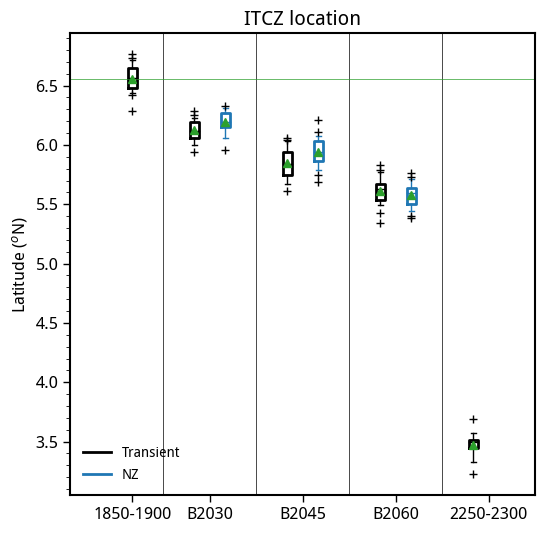

In [49]:
fig = plt.figure(figsize=(6,6))
bp1 = plt.boxplot([itcz_loc_pi, itcz_loc_15, itcz_loc_20, itcz_loc_30, itcz_loc_post21], whis=[5,95], widths=0.3, boxprops=dict(color='k', lw=2.0), medianprops=dict(color='k'), meanprops=dict(marker='^'), showmeans=True, flierprops=dict(marker='+'), positions=[0, 2, 5, 8, 11])
bp2 = plt.boxplot([itcz_loc_15_stable, itcz_loc_20_stable, itcz_loc_30_stable], whis=[5,95], widths=0.3, boxprops=dict(color='tab:blue', lw=2.0), medianprops=dict(color='tab:blue'), meanprops=dict(marker='^'), showmeans=True, whiskerprops=dict(color='tab:blue'), capprops=dict(color='tab:blue'), flierprops=dict(marker='+', color='tab:blue'), positions=[3, 6, 9])
plt.gca().set_xticks([0, 2.5, 5.5, 8.5, 11.5])
plt.gca().set_xticklabels(['1850-1900', 'B2030', 'B2045', 'B2060', '2250-2300'])
plt.ylabel('Latitude ($^{o}$N)')
# plt.xlim(-1, 11)
plt.axvline(1, color='k', lw=0.5)
plt.axvline(4, color='k', lw=0.5)
plt.axvline(7, color='k', lw=0.5)
plt.axvline(10, color='k', lw=0.5)
plt.axhline(itcz_loc_pi.mean(), color='tab:green', lw=0.5)
plt.title('ITCZ location')
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.xlim(-2, 13)
plt.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Transient', 'NZ'], loc='lower left', frameon=False, fontsize=10)


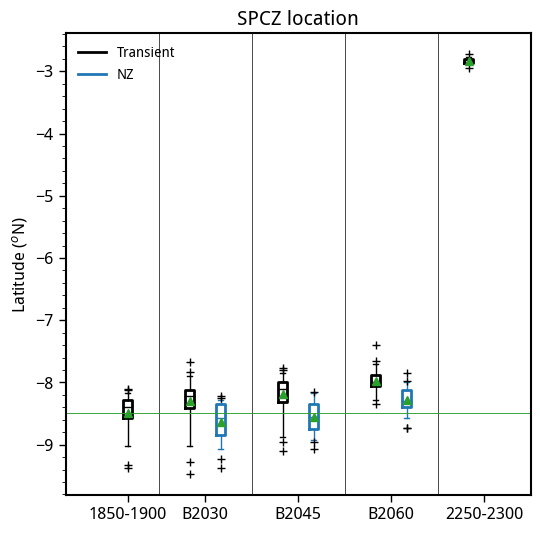

In [50]:
fig = plt.figure(figsize=(6,6))
bp1 = plt.boxplot([spcz_loc_pi, spcz_loc_15, spcz_loc_20, spcz_loc_30, spcz_loc_post21], whis=[5,95], widths=0.3, boxprops=dict(color='k', lw=2.0), medianprops=dict(color='k'), meanprops=dict(marker='^'), showmeans=True, flierprops=dict(marker='+'), positions=[0, 2, 5, 8, 11])
bp2 = plt.boxplot([spcz_loc_15_stable, spcz_loc_20_stable, spcz_loc_30_stable], whis=[5,95], widths=0.3, boxprops=dict(color='tab:blue', lw=2.0), medianprops=dict(color='tab:blue'), meanprops=dict(marker='^'), showmeans=True, whiskerprops=dict(color='tab:blue'), capprops=dict(color='tab:blue'), flierprops=dict(marker='+', color='tab:blue'), positions=[3, 6, 9])
plt.gca().set_xticks([0, 2.5, 5.5, 8.5, 11.5])
plt.gca().set_xticklabels(['1850-1900', 'B2030', 'B2045', 'B2060', '2250-2300'])
plt.ylabel('Latitude ($^{o}$N)')
plt.axvline(1, color='k', lw=0.5)
plt.axvline(4, color='k', lw=0.5)
plt.axvline(7, color='k', lw=0.5)
plt.axvline(10, color='k', lw=0.5)
plt.axhline(spcz_loc_pi.mean(), color='tab:green', lw=0.5)
plt.axhline(spcz_loc_pi.mean(), color='tab:green', lw=0.5)
plt.title('SPCZ location')
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.xlim(-2, 13)
plt.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Transient', 'NZ'], loc='upper left', frameon=False, fontsize=10)

In [26]:
nino34_mag_trans = rolling_window_std(funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15), window_size=30)
nino34_mag_stable = rolling_window_std(funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15), window_size=30)

In [27]:
pac_sstg_trans = rolling_window_smoothing(ts_trans.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - 
                                          ts_trans.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon')), window_size=30)
pac_sstg_stable = rolling_window_smoothing(ts_stable.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - 
                                           ts_stable.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon')), window_size=30)

In [28]:
test = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/ts/gn/latest/*.nc')

In [29]:
import xesmf as xe

In [30]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset>
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 -90.0 -88.5 -88.5 ... 88.5 90.0

In [31]:
regridder = xe.Regridder(test, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [43]:
test_loaded = regridder(funcs.calc_anom(test.ts, test.ts).resample(time = 'AS-JUN').mean('time')).sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).mean(('lat', 'lon')).load()
test_loaded

<xarray.DataArray (time: 1001)>
array([-1.4428723 , -0.22452697,  0.43375292, ..., -0.11087382,
        0.827716  ,  0.8551029 ], dtype=float32)
Coordinates:
  * time                (time) object 0100-06-01 00:00:00 ... 1100-06-01 00:0...
    latitude_longitude  float64 nan

In [46]:
test1 = regridder(funcs.calc_anom(test.ts, test.ts).resample(time = 'AS-JUN').mean('time'))
test1_loaded = (test1.sel(lat=slice(-5,5), lon = slice(140, 170)).mean(('lat', 'lon')) - test1.sel(lat=slice(-5,5), lon = slice(190, 270)).mean(('lat', 'lon'))).load()
test1_loaded

<xarray.DataArray (time: 1001)>
array([ 0.92898154, -0.5019753 , -0.07991815, ..., -0.21396407,
       -0.7917074 , -0.4260388 ], dtype=float32)
Coordinates:
  * time                (time) object 0100-06-01 00:00:00 ... 1100-06-01 00:0...
    latitude_longitude  float64 nan

In [49]:
import seaborn as sns

Text(0.5, 0, 'Time')

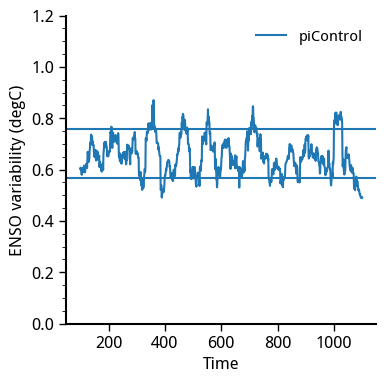

In [50]:
plt.figure(figsize=(4,4))
rolling_std_picontrol = rolling_window_std(funcs.detrend_rolling_window(test_loaded, window_size=15), window_size=30)
plt.plot(rolling_std_picontrol.time.dt.year, rolling_std_picontrol, label='piControl')
plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11)
plt.ylabel('ENSO variability (degC)')
plt.xlabel('Time')


Text(0.5, 0, 'Year')

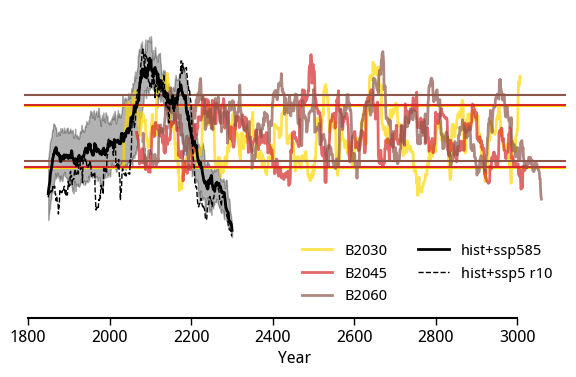

In [57]:
plt.figure(figsize=(7,4))

plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2030'), color='gold', lw=2.0, alpha=0.7, label='B2030')
plt.axhline(nino34_mag_stable.sel(model='B2030').quantile(0.1, dim='time'), color='gold')
plt.axhline(nino34_mag_stable.sel(model='B2030').quantile(0.9, dim='time'), color='gold')
plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2045'), color='tab:red', lw=2.0, alpha=0.7, label='B2045')
plt.axhline(nino34_mag_stable.sel(model='B2045').quantile(0.1, dim='time'), color='tab:red')
plt.axhline(nino34_mag_stable.sel(model='B2045').quantile(0.9, dim='time'), color='tab:red')
plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2060'), color='tab:brown', lw=2.0, alpha=0.7, label='B2060')
plt.axhline(nino34_mag_stable.sel(model='B2060').quantile(0.1, dim='time'), color='tab:brown')
plt.axhline(nino34_mag_stable.sel(model='B2060').quantile(0.9, dim='time'), color='tab:brown')

plt.plot(nino34_mag_trans.time.dt.year, nino34_mag_trans.quantile(0.5, 'model'), color='k', lw=2.0, label='hist+ssp585')
plt.plot(nino34_mag_trans.time.dt.year, nino34_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(nino34_mag_trans.time.dt.year, nino34_mag_trans.quantile(0.1, 'model'), nino34_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine(left=True, trim=True)
plt.yticks([])
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11, loc='lower right', ncol=2)
# plt.ylabel('ENSO variability (degC)')
plt.xlabel('Year')


Text(0.5, 0, 'Time')

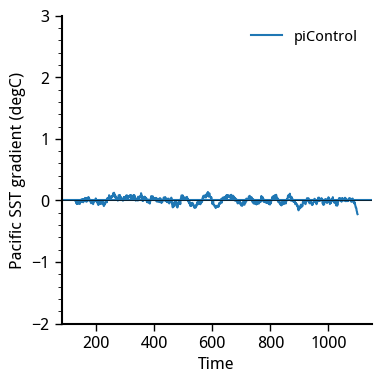

In [52]:
plt.figure(figsize=(4,4))
rolling_sstg_picontrol = rolling_window_smoothing(test1_loaded, window_size=30)
plt.plot(rolling_sstg_picontrol.time.dt.year[30:], rolling_sstg_picontrol[30:], label='piControl')
plt.axhline(rolling_sstg_picontrol[30:].quantile(0.5, dim='time'))
plt.axhline(0.0, color='k', lw=0.5)
plt.ylim(-2, 3)
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11)
plt.ylabel('Pacific SST gradient (degC)')
plt.xlabel('Time')


Text(0.5, 0, 'Year')

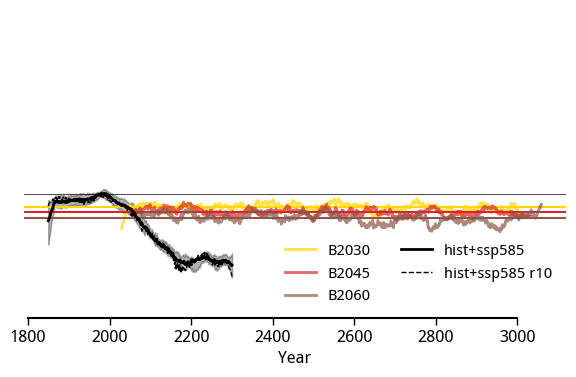

In [58]:
plt.figure(figsize=(7,4))

plt.plot(pac_sstg_stable.time.dt.year, pac_sstg_stable.sel(model = 'B2030'), color='gold', lw=2.0, alpha=0.7, label='B2030')
plt.axhline(pac_sstg_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')
plt.plot(pac_sstg_stable.time.dt.year, pac_sstg_stable.sel(model = 'B2045'), color='tab:red', lw=2.0, alpha=0.7, label='B2045')
plt.axhline(pac_sstg_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')
plt.plot(pac_sstg_stable.time.dt.year, pac_sstg_stable.sel(model = 'B2060'), color='tab:brown', lw=2.0, alpha=0.7, label='B2060')
plt.axhline(pac_sstg_stable.sel(model='B2060').quantile(0.5, dim='time'), color='tab:brown')

plt.plot(pac_sstg_trans.time.dt.year, pac_sstg_trans.quantile(0.5, 'model'), color='k', lw=2.0, label='hist+ssp585')
plt.plot(pac_sstg_trans.time.dt.year, pac_sstg_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
plt.fill_between(pac_sstg_trans.time.dt.year, pac_sstg_trans.quantile(0.1, 'model'), pac_sstg_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(-2, 3)
sns.despine(left=True, trim=True)
plt.yticks([])
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11, loc='lower right', ncol=2)
plt.axhline(0.0, color='k', lw=0.5)
# plt.ylabel('ENSO variability (degC)')
plt.xlabel('Year')


In [ ]:
nino34_mag_pi = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')).sel(time = slice('1850', '1900')), window_size=15).std('time')
nino34_mag15 = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15).where((gmst_trans > 1.3) & (gmst_trans < 1.7), drop=True).std('time')
nino34_mag20 = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15).where((gmst_trans > 1.9) & (gmst_trans < 2.1), drop=True).std('time')
nino34_mag30 = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15).where((gmst_trans > 2.9) & (gmst_trans < 3.1), drop=True).std('time')

In [230]:
nino34_mag15_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15).where((gmst_stable > 1.3) & (gmst_stable < 1.7), drop=True).std('time')
nino34_mag20_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15).where((gmst_stable > 1.9) & (gmst_stable < 2.1), drop=True).std('time')
nino34_mag30_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15).where((gmst_stable > 2.9) & (gmst_stable < 3.1), drop=True).std('time')

{'whiskers': [<matplotlib.lines.Line2D at 0x7fc4e55d8310>,
 'caps': [<matplotlib.lines.Line2D at 0x7fc4e55d88b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fc4e55d8040>,
 'medians': [<matplotlib.lines.Line2D at 0x7fc4e55d8e50>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fc4e55e7160>,
 'means': []}

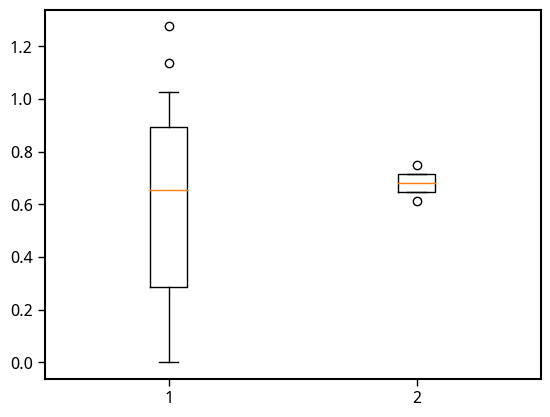

In [232]:
plt.boxplot([nino34_mag30, nino34_mag30_stable], whis=[5,95])

In [189]:
d15 = (np.abs(itcz_loc_15) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_15) + (spcz_loc_pi))
d20 = (np.abs(itcz_loc_20) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_20) + (spcz_loc_pi))
d30 = (np.abs(itcz_loc_30) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_30) + (spcz_loc_pi))
d40 = (np.abs(itcz_loc_40) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_40) + (spcz_loc_pi))

In [162]:
d15_stable = (np.abs(itcz_loc_15_stable) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_15_stable) + (spcz_loc_pi))
d20_stable = (np.abs(itcz_loc_20_stable) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_20_stable) + (spcz_loc_pi))
d30_stable = (np.abs(itcz_loc_30_stable) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_30_stable) + (spcz_loc_pi))
# d40_stable = (np.abs(itcz_loc_40_stable) - np.abs(itcz_loc_pi)) + (np.abs(spcz_loc_40_stable) + (spcz_loc_pi))

ValueError: operands could not be broadcast together with shapes (35,) (40,) 

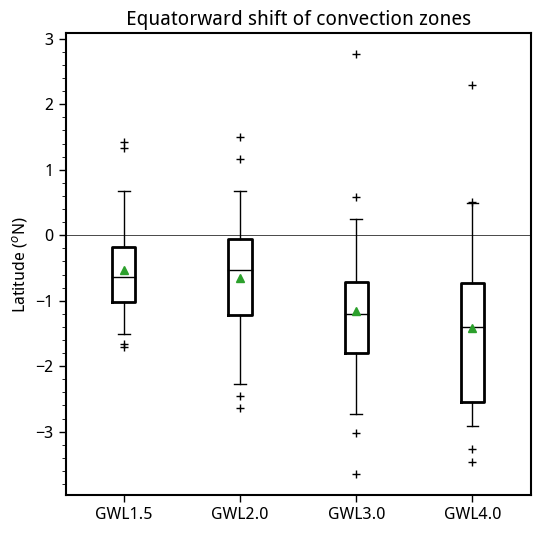

In [190]:
fig = plt.figure(figsize=(6,6))
plt.boxplot([d15, d20, d30, d40], whis=[5,95], widths=0.2, boxprops=dict(color='k', lw=2.0), medianprops=dict(color='k'), meanprops=dict(marker='^'), showmeans=True, flierprops=dict(marker='+'))
plt.gca().set_xticklabels(['GWL1.5', 'GWL2.0', 'GWL3.0', 'GWL4.0'])
plt.ylabel('Latitude ($^{o}$N)')
plt.title('Equatorward shift of convection zones')
plt.axhline(0.0, color='k', lw=0.5)
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')

In [55]:
hist_files = []
ssp_files = []
for i in range(1, 41):
    hist_files.append(xr.open_mfdataset(f'/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r{i}i1p1f1/Amon/vas/gn/latest/*.nc', use_cftime=True))
    ssp_files.append(xr.open_mfdataset(f'/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp585/r{i}i1p1f1/Amon/vas/gn/latest/*.nc', use_cftime=True))
    vas_hist = xr.concat(hist_files, "model")
    vas_ssp = xr.concat(ssp_files, "model")
    # uas_hist['model'] = np.arange(1,41)
    # uas_ssp['model'] = np.arange(1,41)
    # uas = xr.concat([uas_hist, uas_ssp], dim='time')

KeyboardInterrupt: 

In [35]:
vas = xr.concat([vas_hist, vas_ssp], 'time')
vas['model'] = np.arange(1, 41, 1)

In [36]:
uas

<xarray.Dataset>
Dimensions:    (time: 5412, model: 40, bnds: 2, lat: 145, lon: 192)
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2300-12-16 12:00:00
  * lat        (lat) float64 -90.0 -88.75 -87.5 -86.25 ... 86.25 87.5 88.75 90.0
  * lon        (lon) float64 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 10.0
  * model      (model) int64 1 2 3 4 5 6 7 8 9 10 ... 32 33 34 35 36 37 38 39 40
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (model, time, bnds) object dask.array<chunksize=(1, 1980, 2), meta=np.ndarray>
    lat_bnds   (model, lat, bnds, time) float64 dask.array<chunksize=(1, 145, 2, 1980), meta=np.ndarray>
    lon_bnds   (model, lon, bnds, time) float64 dask.array<chunksize=(1, 192, 2, 1980), meta=np.ndarray>
    uas        (model, time, lat, lon) float32 dask.array<chunksize=(1, 1980, 145, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  21915.0
    creation_date:          2019-11-15T04:03:09Z
    ...                     ...
    variable_id:            uas
    variant_label:          r1i1p1f1
    version:                v20191115
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/c3411b7b-06de-463f-8aff-1739abfca386
    license:                CMIP6 model data produced by CSIRO is licensed un...

In [ ]:
vas

##  next steps are to regrid and then resample and then save the files 